You could use this notebook on [Google Colab](https://colab.research.google.com/) with a GPU Hardware Accelerator runtype.

# RAW DATA
Install dependencies and retrieve all games from 1983-present using the nba_api library. The API library limits the size of each individual request. To warehouse my final dataset I will request each season's games separately then concatenate the responses together into one dataframe.


In [1]:
#For some reason pip3 install -r requirements.txt doesn't work on Colab
! pip3 install -r requirements.txt


[notice] A new release of pip available: 22.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from nba_api.stats.endpoints import teamgamelog, cumestatsteamgames, cumestatsteam, gamerotation, boxscoreadvancedv3, leaguegamefinder
from nba_api.stats.static import teams, players
import matplotlib.pyplot as plt
import seaborn as sns
import json

pd.option_context('mode.chained_assignment', None)
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [109]:
def get_season(season: str) -> pd.DataFrame:
    # Input: season string with format '2011-12'
    # Output: pandas dataframe of all regular season games in the NBA for that season
    result = leaguegamefinder.LeagueGameFinder(league_id_nullable='00', season_type_nullable='Regular Season', season_nullable=season)
    season_games = result.get_data_frames()[0]
    return season_games

all_seasons = []
for start_year in range(1983, 2025):
    end_year_suffix = (start_year + 1) % 100 # last two digits of end year
    season_str = f'{start_year}-{end_year_suffix:02d}'
    print(season_str)
    season_df = get_season(season_str)
    all_seasons.append(season_df)

all_games = pd.concat(all_seasons, ignore_index=True)


1983-84
1984-85
1985-86
1986-87
1987-88
1988-89
1989-90
1990-91
1991-92
1992-93
1993-94
1994-95
1995-96
1996-97
1997-98
1998-99
1999-00
2000-01
2001-02
2002-03
2003-04
2004-05
2005-06


ReadTimeout: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)

# DATA UNDERSTANDING
A key to the usefulness of this program is understanding the dataset. Knowing the limitations of the current data adds context to the predictions made by the program. This dataset contains 95,774 games with 20 numerical attributes and seven categorical attributes. The categorical attributes are mostly IDs for identifying the season, team, game, and date. The dataset is relatively clean to start, the only missing values are PLUS_MINUS prior to the 1996 season. 

In [110]:
# Plus-minus was not included until the 1996 season resulting in NaN values for all prior seasons
# could just remove those seasons
print(all_games.columns)
print(f'Total games: {len(all_games)}')

Index(['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID',
       'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG3M',
       'FG3A', 'FTM', 'FTA', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV', 'PF'],
      dtype='object')
Total games: 95774


## Feature Definitions

Each row represents one team's statistics for a game. The other team in the matchup is represented in a different row  
TEAM_NAME: Name of the home team.  
MIN: total minutes logged by players. Will generally   
FGM: Made field goals  
FGA: total attempted field goals  
FG_PCT: percentage of field goals made  
FG3M: three point field goals made  
FG3A: three point field goals attempted  
FG3_PCT: percentage of three point field goals made  
FTM: free throws made  
FTA: free throws attempted   
FT_PCT: percentage of free throws made  
OREB: offensive rebounds  
DREB: defensive rebounds  
REB: total rebounds  
AST: assists  
TOV: turnovers  
STL: steals  
BLK: blocks  
PF: personal fouls   
PTS: total points  
PLUS_MINUS: point differential 

In [ ]:
# make season ID more readable
all_games['SEASON_ID'] = all_games['SEASON_ID'].apply(lambda x: x[1:])

In [120]:
# Example matchup
all_games[(all_games['SEASON_ID']=='2024')&(all_games['TEAM_ABBREVIATION']=='BOS')]['TOV'].mean()

11.353658536585366

Max points: 186
Min points: 49


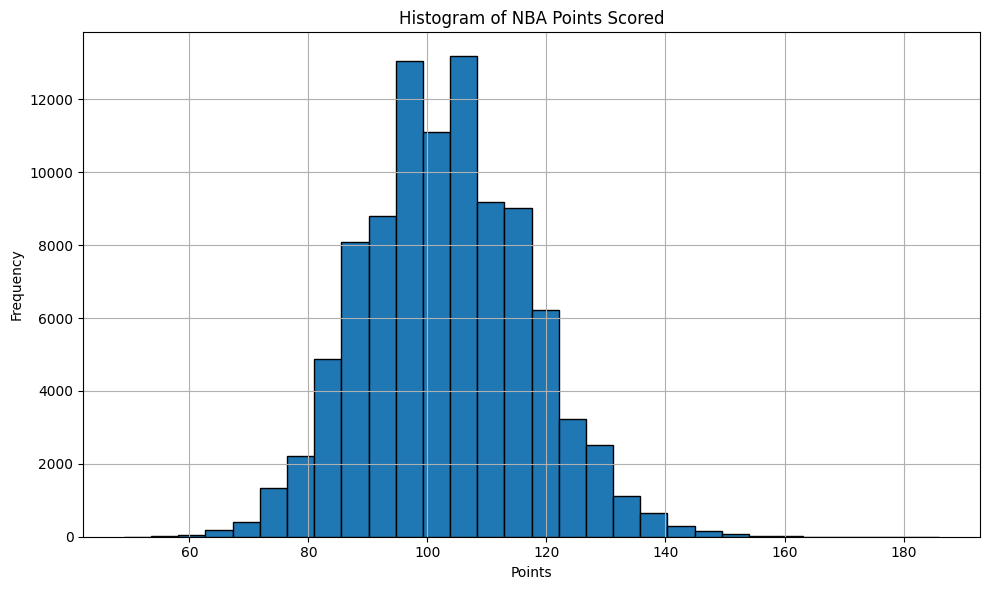

In [112]:
# Plot histogram for 'PTS' column
print(f"Max points: {all_games['PTS'].max()}")
print(f"Min points: {all_games['PTS'].min()}")
plt.figure(figsize=(10, 6))
plt.hist(all_games['PTS'].dropna(), bins=30, edgecolor='black')  # Drop NaN values for cleaner data
plt.title('Histogram of NBA Points Scored')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

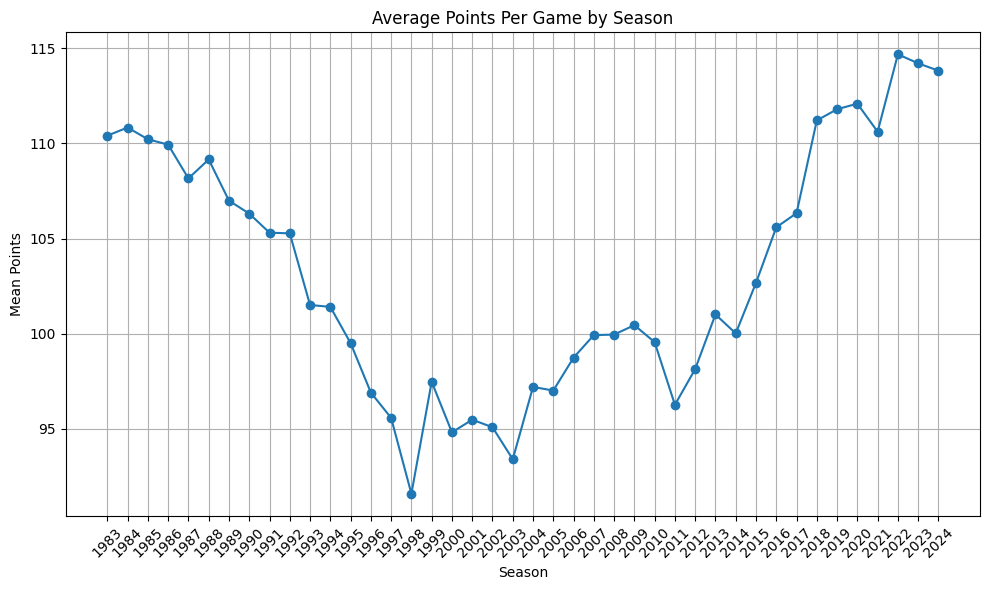

In [42]:
# Compute mean points per season
mean_pts_per_season = all_games.groupby('SEASON_ID')['PTS'].mean().reset_index()
mean_pts_per_season.columns = ['SEASON_ID', 'Mean_PTS']

# plot the result
plt.figure(figsize=(10, 6))
plt.plot(mean_pts_per_season['SEASON_ID'], mean_pts_per_season['Mean_PTS'], marker='o')

plt.title('Average Points Per Game by Season')
plt.xlabel('Season')
plt.ylabel('Mean Points')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.grid(True)
plt.tight_layout()
plt.show()

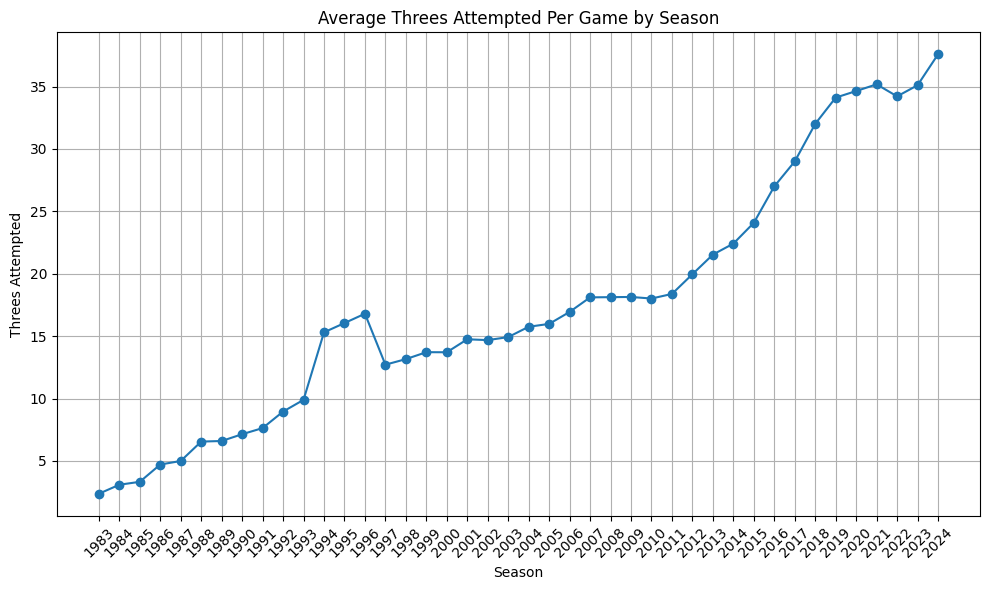

In [45]:
# Compute average 3-point field goals made and plot change over time
mean_pts_per_season = all_games.groupby('SEASON_ID')['FG3A'].mean().reset_index()
mean_pts_per_season.columns = ['SEASON_ID', 'Mean_FG3A']

# plot the result
plt.figure(figsize=(10, 6))
plt.plot(mean_pts_per_season['SEASON_ID'], mean_pts_per_season['Mean_FG3A'], marker='o')

plt.title('Average Threes Attempted Per Game by Season')
plt.xlabel('Season')
plt.ylabel('Threes Attempted')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.grid(True)
plt.tight_layout()
plt.show()

## Trends
We can see a decrease a steady decrease in points year-over-year until the 1998 season. This decrease could be attributed to a greater emphasis on defense and physical play. The 1998 season was shortened to 50 games due to a lockout leading to less preparation time and lower scoring. Several rule changes including defensive three-second violations and a hand-checking prohibition resulted in more offensive freedom and scoring. The most dramatic effect on overall scoring, however, is the three-point revolution. Teams have place a strategic emphasis on three point scoring resulting in an increase from less than 3 threes attempted per game in the 80s to over 30 today.

Since points is the label my models will predict I spent the most time trying to understand this feature. Points scored follows a relatively normal distribution as can be seen from the histogram

# DATA CLEANING
As can be seen in the correlation matrix some attributes are highly correlated with each other. For example, free throws made are highly correlated with free throws attempted since the percentage made is relatively stable across the league. While shot attempts is highly correlated with shot makes attempts capture important information about a team's pace of play and shot selection which both influence total points. Attempts and makes represent complementary, not redundant, attributes and both will be retained for training the dataset.

There are, however, some derived attributes in the dataset which represent redundant information. Shot percentage for all three types of shots (free throws, field goals, three-point field goals) can be derived from shots made / shots attempted so it can be dropped. Total rebounds also can be derived from offensive rebounds + defensive rebounds. Since it is less granular than the two individual rebound types it can also be dropped.

The final attribute which can be dropped is plus-minus. This statistic is more informative on the player level since it represents the point differential while that player is on the court. At the team level plus-minus will always be the point differential for the game, already reflected in the points attribute. This statistic was also not recorded until 1996 so rather than imputing missing values I will drop it entirely. 

# TODO
Normalize points. Maybe normalize other attributes?

In [ ]:
all_games.drop(['FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'PLUS_MINUS'], axis=1, inplace=True)
all_games.columns

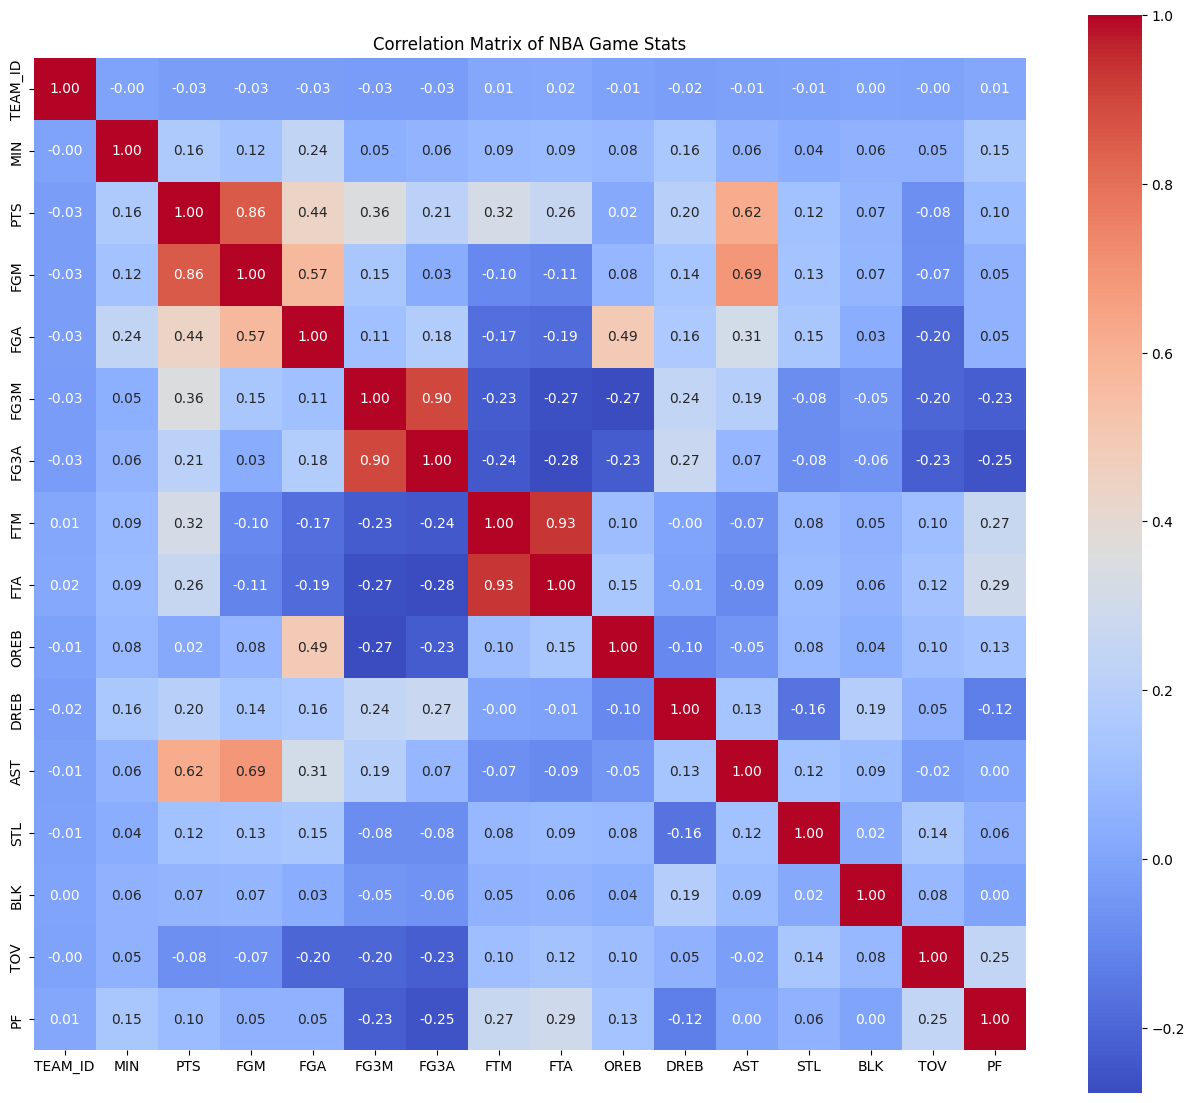

In [114]:
correlation_matrix = all_games.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Correlation Matrix of NBA Game Stats")
plt.show()

In [ ]:
# sort games by date and ID to group matchups together
all_games['GAME_DATE'] = pd.to_datetime(all_games['GAME_DATE'], format='%Y-%m-%d')
sorted_games = all_games.sort_values(['GAME_DATE', 'GAME_ID'], ascending=True)
sorted_games.tail(2)

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF
93319,2024,1610612756,PHX,Phoenix Suns,0022401200,2025-04-13,PHX @ SAC,L,241,98,40,84,15,44.0,3,6,9.0,28.0,28,6.0,1,11,9
93322,2024,1610612758,SAC,Sacramento Kings,0022401200,2025-04-13,SAC vs. PHX,W,243,109,46,88,14,34.0,3,3,10.0,33.0,31,6.0,4,11,7


# DATA MODELING  

### MARKOV CHAIN MODEL
I will start with a Markov Chain Model. This method of modeling sequential data uses team score as state. The next game's score only depends on the previous game's score. While this method ignores important factors such as matchup strength it will capture information about common two-game subsequences. This model will also function as an efficient starting point to which the more computationally expensive neural networks can be compared. 

In [98]:
# Markov Chain Model
def build_markov_chain(df, bin_size=5):
    # Bin setup
    min_score = df['PTS_normalized'].min()
    max_score = df['PTS_normalized'].max()

    bins = np.arange(min_score - bin_size, max_score + bin_size, bin_size)
    bins = np.asarray(bins).flatten()
    n_bins = len(bins)
    
    # Matrix to accumulate transitions across all teams
    matrix = np.zeros((n_bins, n_bins))
    
    # Loop through each team and collect transitions from their sequence of games
    for team_id, group in df.groupby('TEAM_ID'):
        group_sorted = group.sort_values('GAME_DATE')
        pts = group_sorted['PTS_normalized'].values
        states = np.digitize(pts, bins, right=True)
        
        for prev, curr in zip(states[:-1], states[1:]):
            matrix[prev, curr] += 1

    # Normalize rows to get probabilities
    row_sums = matrix.sum(axis=1, keepdims=True)
    transition_probs = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums != 0)
    
    return transition_probs, bins


def predict_next_score(last_score, transition_probs, bins):
    last_state = np.digitize([last_score], bins, right=True)[0]
    next_state = np.argmax(transition_probs[last_state])
    # Return the center of the bin as the prediction
    bin_low = bins[next_state - 1] if next_state > 0 else 0
    bin_high = bins[next_state]
    return (bin_low + bin_high) / 2

def plot_transition_matrix(transition_probs, bins):
    plt.figure(figsize=(16, 14))
    sns.heatmap(
        transition_probs, 
        annot=True, 
        fmt=".2f", 
        cmap="Blues", 
        xticklabels=[f"{b}" for b in bins], 
        yticklabels=[f"{b}" for b in bins]
    )
    plt.title("Markov Chain Transition Matrix (Score Bins)")
    plt.xlabel("Next Game Score Bin")
    plt.ylabel("Previous Game Score Bin")
    plt.tight_layout()
    plt.show()

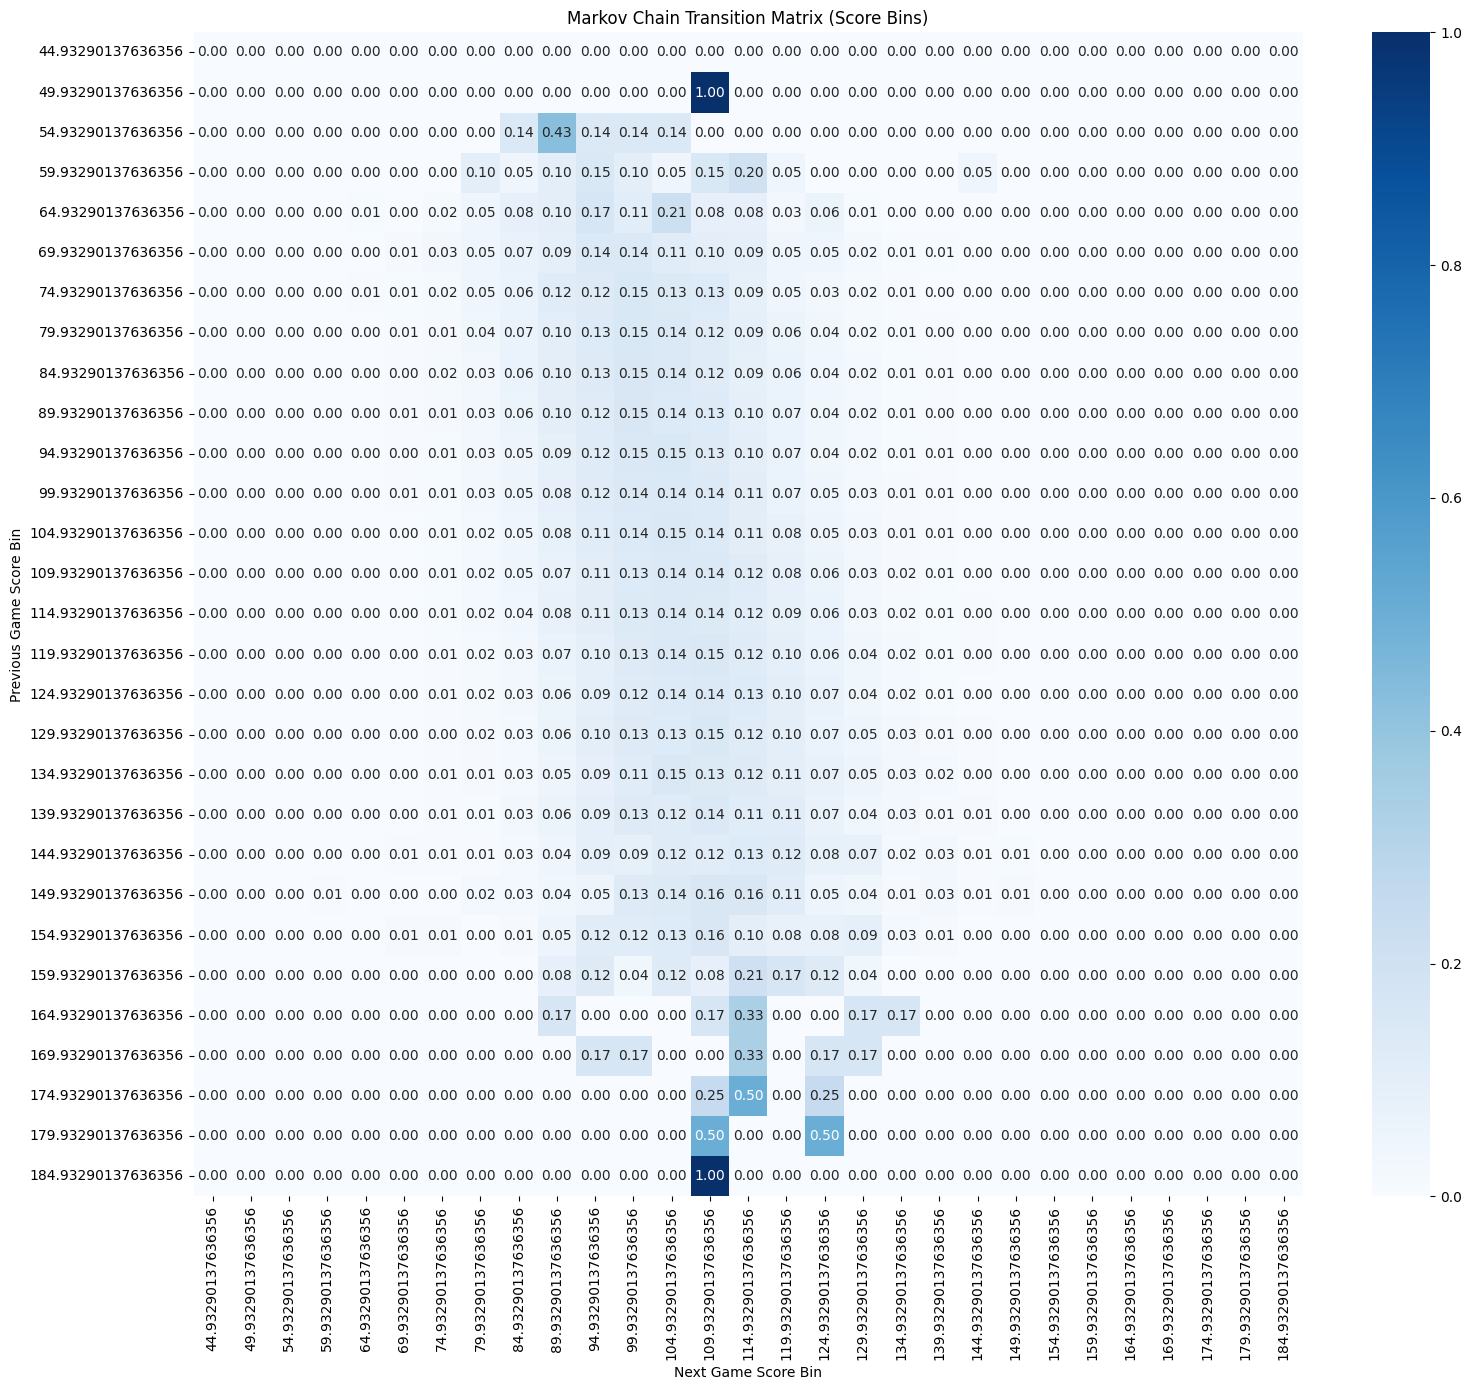

In [99]:
# Group by season and compute mean and std
season_stats = sorted_games.groupby('SEASON_ID')['PTS'].agg(['mean', 'std']).reset_index()
season_stats.columns = ['SEASON_ID', 'season_mean', 'season_std']

overall_mean = sorted_games['PTS'].mean()
overall_std = sorted_games['PTS'].std()

# Merge back into original DataFrame
normalized = sorted_games.merge(season_stats, on='SEASON_ID')

# Compute z-score
normalized['PTS_normalized'] = ((normalized['PTS'] - normalized['season_mean']) * overall_std / normalized['season_std']) + overall_mean

# Train/test split
train = normalized[normalized['SEASON_ID'] != '2024']
test = normalized[normalized['SEASON_ID'] == '2024']

# Build model
transition_probs, bins = build_markov_chain(train)

# Visualize transition matrix
plot_transition_matrix(transition_probs, bins)

In [106]:
print(overall_mean)
print(overall_std)

103.15794474492033
13.769060283093573


What stands out from the transition matrix are the outlier games. There is only one game in NBA history where 189 points were scored and 119 points were scored by the team in their next game. This results in a 100% probability in the transition matrix between 189 and 119. Otherwise, the transition probabilities seem normally distributed around the league average.

In [102]:
# Evaluate model using test set
actual_pts = []
predicted_pts = []

# Loop through test set
for team, group in test.groupby('TEAM_ID'):
    group = group.sort_values('GAME_DATE')
    team_train = train[train['TEAM_ID'] == team].sort_values('GAME_DATE')

    # Get last train game to seed prediction
    last_train_game = team_train.iloc[-1] if not team_train.empty else None
    if last_train_game is not None:
        prev_pts = last_train_game['PTS_normalized']

        for _, row in group.iterrows():
            pred = predict_next_score(prev_pts, transition_probs, bins)
            predicted_pts.append(pred)
            actual_pts.append(row['PTS_normalized'])
            prev_pts = row['PTS_normalized']  # update for next game

In [103]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(actual_pts, predicted_pts)
print(f"Mean Absolute Error on test set: {mae:.2f}")

Mean Absolute Error on test set: 11.04


### Feedforward Neural Network
Next, I will train a feedforward neural network. For features I will use a team's average statistics and the matchup's average statistics for the season. The label used will be points scored. I do not plan on standardizing statistics from different seasons to a common distribution like with the Markov Chain Model. Standardization would lead to consistency across eras but reduce the interpretability of the model. This consistency is not as important for a neural network as a transition model. 

In [178]:
sorted_games.head(2)

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF
1876,1983,1610612754,IND,Indiana Pacers,0028300001,1983-10-28,IND @ MIL,L,240,83,35,104,0,0.0,13,21,24.0,29.0,27,7.0,4,19,22
1882,1983,1610612749,MIL,Milwaukee Bucks,0028300001,1983-10-28,MIL vs. IND,W,240,104,42,97,0,1.0,20,26,21.0,39.0,24,12.0,13,19,22


In [ ]:
# Convert MATCHUP column to binary AT_HOME
sorted_games['AT_HOME'] = sorted_games['MATCHUP'].str.contains('vs')
sorted_games.drop(['MATCHUP'], axis=1, inplace=True)
sorted_games.head(2)

In [230]:
sorted_games['AT_HOME'] = sorted_games['AT_HOME'].astype(int)

In [273]:
games_rest = sorted_games.sort_values(['TEAM_ID', 'GAME_DATE']).reset_index(drop=True)
games_rest['DAYS_REST'] = games_rest.groupby('TEAM_ID')['GAME_DATE'].diff().dt.days
games_rest['DAYS_REST'] = games_rest['DAYS_REST'].clip(upper=7)
games_rest.head()


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF,AT_HOME,DAYS_REST
0,1983,1610612737,ATL,Atlanta Hawks,0028300005,1983-10-28,L,240,108,41,90,0,0.0,26,38,15.0,18.0,14,10.0,5,17,30,0,NaN
1,1983,1610612737,ATL,Atlanta Hawks,0028300014,1983-10-29,W,240,117,49,94,0,1.0,19,30,27.0,21.0,28,14.0,7,23,35,1,1.0
2,1983,1610612737,ATL,Atlanta Hawks,0028300027,1983-11-01,W,240,95,38,81,0,0.0,19,30,12.0,29.0,20,7.0,10,16,34,1,3.0
3,1983,1610612737,ATL,Atlanta Hawks,0028300041,1983-11-04,W,240,103,42,86,1,1.0,18,26,19.0,27.0,31,14.0,13,18,27,1,3.0
4,1983,1610612737,ATL,Atlanta Hawks,0028300058,1983-11-06,L,240,84,32,78,0,2.0,20,30,11.0,26.0,18,4.0,5,14,24,0,2.0


In [274]:
# First, make sure games are sorted
games = games_rest.sort_values(['TEAM_ABBREVIATION', 'SEASON_ID', 'GAME_DATE'])

# List of stats you want cumulative averages for
stat_columns = ['PTS', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'PF']

# Compute cumulative season averages
for stat in stat_columns:
    games[f'{stat}_season_avg'] = (
        games.groupby(['TEAM_ABBREVIATION', 'SEASON_ID'])[stat]
             .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
    )

In [275]:
games[games['SEASON_ID']=='2023'].head(2)

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF,AT_HOME,DAYS_REST,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg
3207,2023,1610612737,ATL,Atlanta Hawks,0022300063,2023-10-25,L,240,110,39,93,5,29.0,27,33,12.0,30.0,24,12.0,1,12,19,0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3208,2023,1610612737,ATL,Atlanta Hawks,0022300079,2023-10-27,L,240,120,42,87,12,32.0,24,30,9.0,35.0,28,7.0,6,14,20,1,2.0,110.0,12.0,30.0,24.0,12.0,1.0,12.0,39.0,93.0,5.0,29.0,27.0,33.0,19.0


In [276]:
# Add opponent's season average statistics
# Get row with same game_id but different team_abbreviation
# Select the columns you want to merge from the opponent
opponent_cols = ['GAME_ID', 'TEAM_ABBREVIATION'] + [f'{stat}_season_avg' for stat in stat_columns]

# Rename columns to indicate opponent
opponent_data = games[opponent_cols].copy()
opponent_data = opponent_data.rename(columns={col: f'OPP_{col}' for col in opponent_cols if col != 'GAME_ID'})

In [277]:
# Step 2: Merge on GAME_ID
games_with_opponent = games.merge(opponent_data, on='GAME_ID', how='left')

# Step 3: Filter out where TEAM_ID == OPP_TEAM_ID (i.e., self matches)
games_with_opponent = games_with_opponent[games_with_opponent['TEAM_ABBREVIATION'] != games_with_opponent['OPP_TEAM_ABBREVIATION']]

In [278]:
games_with_opponent[games_with_opponent['GAME_ID']=='0022300097']

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,WL,MIN,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,AST,STL,BLK,TOV,PF,AT_HOME,DAYS_REST,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg,OPP_TEAM_ABBREVIATION,OPP_PTS_season_avg,OPP_OREB_season_avg,OPP_DREB_season_avg,OPP_AST_season_avg,OPP_STL_season_avg,OPP_BLK_season_avg,OPP_TOV_season_avg,OPP_FGM_season_avg,OPP_FGA_season_avg,OPP_FG3M_season_avg,OPP_FG3A_season_avg,OPP_FTM_season_avg,OPP_FTA_season_avg,OPP_PF_season_avg
6419,2023,1610612737,ATL,Atlanta Hawks,0022300097,2023-10-29,W,241,127,47,93,15,37.0,18,22,13.0,33.0,32,15.0,2,17,17,0,2.0,115.0,10.5,32.5,26.0,9.5,3.5,13.0,40.5,90.0,8.5,30.5,25.5,31.5,19.5,MIL,118.0,8.0,35.0,20.0,9.0,4.0,14.0,41.0,81.0,11.0,30.0,25.0,36.0,23.0
105038,2023,1610612749,MIL,Milwaukee Bucks,0022300097,2023-10-29,L,240,110,39,86,16,44.0,16,20,12.0,27.0,22,10.0,3,23,22,1,3.0,118.0,8.0,35.0,20.0,9.0,4.0,14.0,41.0,81.0,11.0,30.0,25.0,36.0,23.0,ATL,115.0,10.5,32.5,26.0,9.5,3.5,13.0,40.5,90.0,8.5,30.5,25.5,31.5,19.5


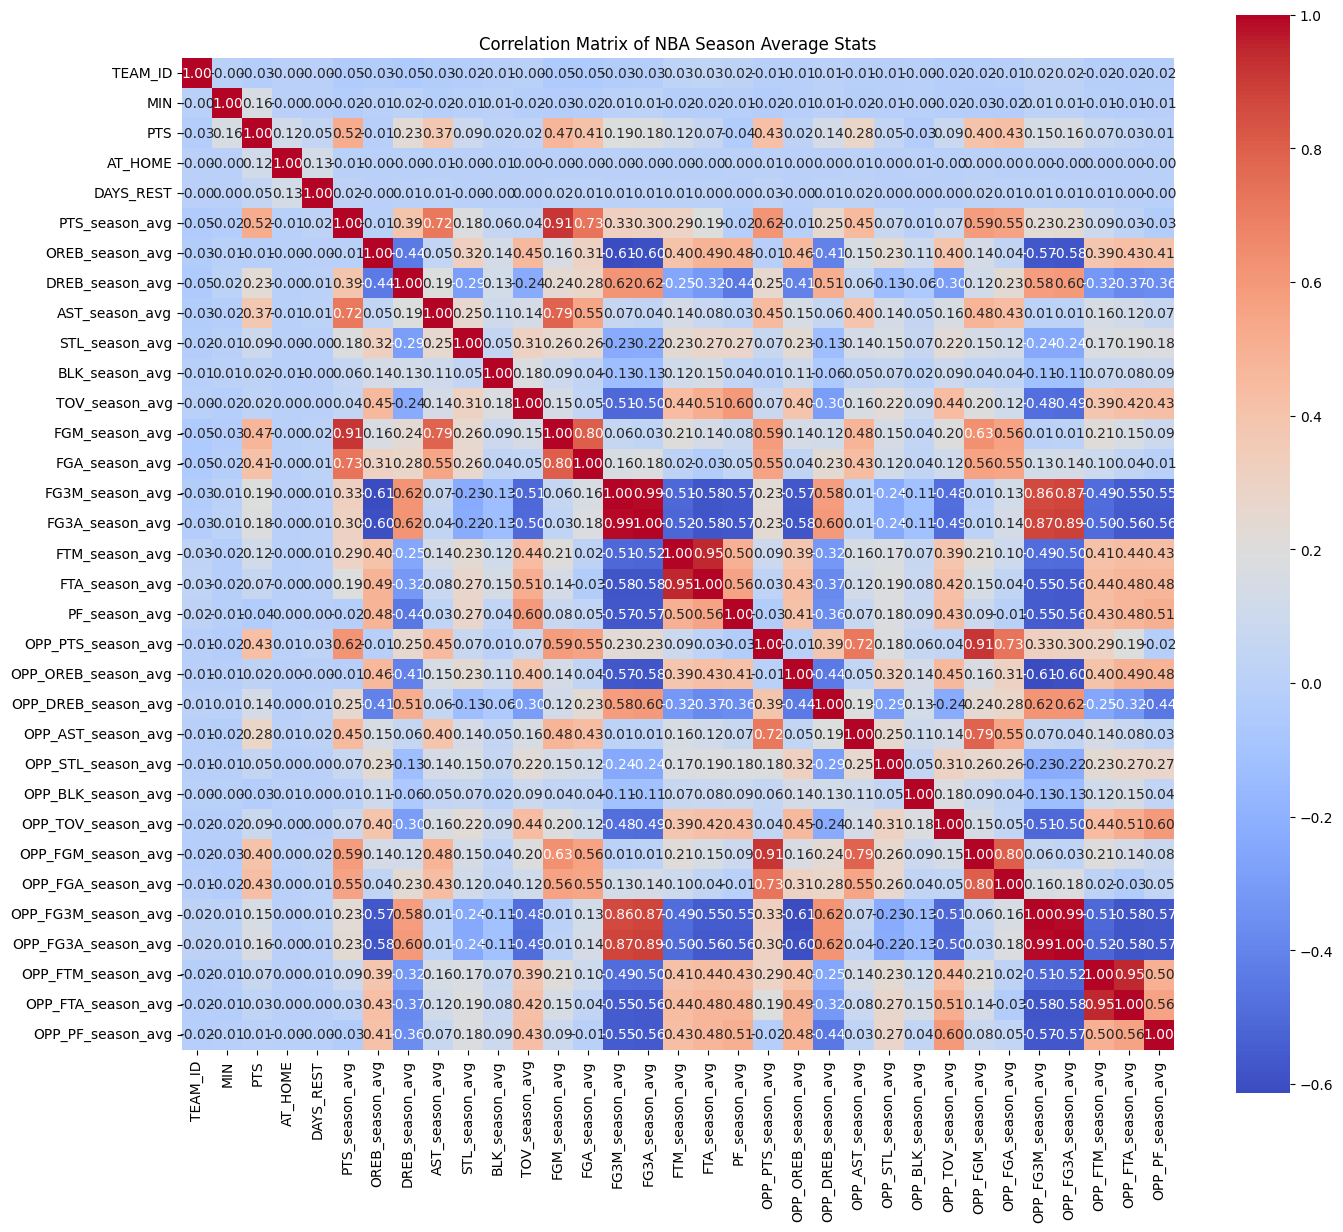

In [279]:
season_avg_df = games_with_opponent.drop(['OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'PF'], axis=1)
season_avg_df.dropna(subset=['PTS_season_avg', 'OPP_PTS_season_avg'], inplace=True)
correlation_matrix = season_avg_df.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Correlation Matrix of NBA Season Average Stats")
plt.show()

In [281]:
# Train/test split
ff_train = season_avg_df[(season_avg_df['SEASON_ID'] != '2024') & (season_avg_df['SEASON_ID']!='2023')]
ff_val = season_avg_df[season_avg_df['SEASON_ID'] == '2023']
ff_test = season_avg_df[season_avg_df['SEASON_ID'] == '2024']


# Features (your team and opponent rolling stats)
feature_cols = [col for col in season_avg_df.columns if '_season_avg' in col] + ['AT_HOME', 'DAYS_REST']

# Target (what you want to predict)
target_col = 'PTS'  # or normalized 'PTS_normalized', depending

X_train = ff_train[feature_cols]
y_train = ff_train[target_col]

X_val = ff_val[feature_cols]
y_val = ff_val[target_col]

X_test = ff_test[feature_cols]
y_test = ff_test[target_col]

print(f'Training lengths: {len(X_train)}, {len(y_train)}')
print(f'Validation lengths: {len(X_val)}, {len(y_val)}')
print(f'Testing lengths: {len(X_test)}, {len(y_test)}')
print(X_train.columns)

Training lengths: 89582, 89582
Validation lengths: 2430, 2430
Testing lengths: 2428, 2428
Index(['PTS_season_avg', 'OREB_season_avg', 'DREB_season_avg',
       'AST_season_avg', 'STL_season_avg', 'BLK_season_avg', 'TOV_season_avg',
       'FGM_season_avg', 'FGA_season_avg', 'FG3M_season_avg',
       'FG3A_season_avg', 'FTM_season_avg', 'FTA_season_avg', 'PF_season_avg',
       'OPP_PTS_season_avg', 'OPP_OREB_season_avg', 'OPP_DREB_season_avg',
       'OPP_AST_season_avg', 'OPP_STL_season_avg', 'OPP_BLK_season_avg',
       'OPP_TOV_season_avg', 'OPP_FGM_season_avg', 'OPP_FGA_season_avg',
       'OPP_FG3M_season_avg', 'OPP_FG3A_season_avg', 'OPP_FTM_season_avg',
       'OPP_FTA_season_avg', 'OPP_PF_season_avg', 'AT_HOME', 'DAYS_REST'],
      dtype='object')


In [282]:
X_train.head()

,PTS_season_avg,OREB_season_avg,DREB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG3M_season_avg,FG3A_season_avg,FTM_season_avg,FTA_season_avg,PF_season_avg,OPP_PTS_season_avg,OPP_OREB_season_avg,OPP_DREB_season_avg,OPP_AST_season_avg,OPP_STL_season_avg,OPP_BLK_season_avg,OPP_TOV_season_avg,OPP_FGM_season_avg,OPP_FGA_season_avg,OPP_FG3M_season_avg,OPP_FG3A_season_avg,OPP_FTM_season_avg,OPP_FTA_season_avg,OPP_PF_season_avg,AT_HOME,DAYS_REST
3,108.000000,15.00,18.000000,14.000000,10.000000,5.000000,17.000000,41.000000,90.000000,0.00,0.000000,26.000000,38.000000,30.0,127.000000,17.00,27.0,26.00,8.000000,7.000000,12.000000,42.000000,100.000000,0.0,1.00,43.0,51.000000,33.000000,1,1.0
5,112.500000,21.00,19.500000,21.000000,12.000000,6.000000,20.000000,45.000000,92.000000,0.00,0.500000,22.500000,34.000000,32.5,105.500000,12.50,30.5,26.50,8.500000,3.000000,22.000000,39.000000,81.500000,0.0,2.00,27.5,35.000000,33.500000,1,3.0
7,106.666667,18.00,22.666667,20.666667,10.333333,7.333333,18.666667,42.666667,88.333333,0.00,0.333333,21.333333,32.666667,33.0,100.666667,16.00,29.0,20.00,9.333333,4.666667,19.333333,36.333333,92.333333,1.0,3.00,27.0,35.333333,30.666667,1,3.0
9,105.750000,18.25,23.750000,23.250000,11.250000,8.750000,18.500000,42.500000,87.750000,0.25,0.500000,20.500000,31.000000,31.5,101.500000,12.75,25.5,25.75,8.250000,6.500000,16.750000,40.500000,81.750000,1.0,2.75,19.5,26.750000,24.750000,0,2.0
11,101.400000,16.80,24.200000,22.200000,9.800000,8.000000,17.600000,40.400000,85.800000,0.20,0.800000,20.400000,30.800000,30.0,107.000000,19.40,23.8,23.60,12.400000,2.800000,17.400000,39.400000,92.600000,0.4,2.00,27.8,37.400000,31.400000,0,2.0


In [283]:
from sklearn.preprocessing import StandardScaler

# Normalize features and convert to tensor
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [284]:
print(np.isnan(X_train).sum(), np.isnan(y_train).sum())
print(np.isnan(X_test).sum(), np.isnan(y_test).sum())
print(X_train.shape)

0 0
0 0
(89582, 30)


In [286]:
from tensorflow import keras
from tensorflow.keras import layers

# Build model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(15, activation='relu'),
    layers.Dense(1)  # Single output for points
])

model.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.001), loss='mean_squared_error')

In [291]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # Watch validation loss
    patience=20,           # Stop after 5 epochs with no improvement
    restore_best_weights=True  # Roll back to best model
)

history = model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
2800/2800 [==============================] - 3s 956us/step - loss: 122.9662 - val_loss: 150.8104
Epoch 2/50
2800/2800 [==============================] - 3s 989us/step - loss: 123.0030 - val_loss: 142.8649
Epoch 3/50
2800/2800 [==============================] - 3s 964us/step - loss: 122.9556 - val_loss: 154.1110
Epoch 4/50
2800/2800 [==============================] - 3s 971us/step - loss: 122.9806 - val_loss: 145.4337
Epoch 5/50
2800/2800 [==============================] - 3s 963us/step - loss: 122.9238 - val_loss: 143.4814
Epoch 6/50
2800/2800 [==============================] - 3s 970us/step - loss: 122.9745 - val_loss: 145.7778
Epoch 7/50
2800/2800 [==============================] - 3s 1ms/step - loss: 122.8953 - val_loss: 142.0174
Epoch 8/50
2800/2800 [==============================] - 3s 993us/step - loss: 122.9743 - val_loss: 144.2643
Epoch 9/50
2800/2800 [==============================] - 3s 1ms/step - loss: 122.9036 - val_loss: 159.1776
Epoch 10/50
2800/2800 [=========

76/76 [==============================] - 0s 914us/step
Test MAE: 9.63


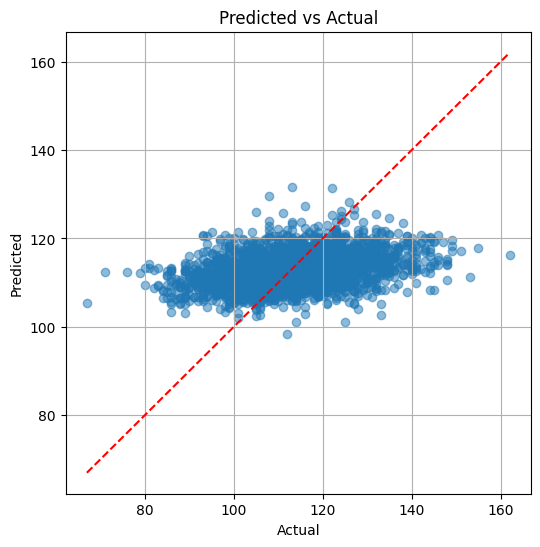

In [292]:
# Predict on test set
y_pred = model.predict(X_test)

# Compute MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {mae:.2f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(True)
plt.show()

In [293]:
print(f"Actual std: {np.std(y_test):.2f}")
print(f"Predicted std: {np.std(y_pred):.2f}")


Actual std: 12.73
Predicted std: 3.92


### Recurrent Neural Network
Designed for sequential data like basketball games I will feed the network a team's most recent 5 games and opponent's most recent 5 games as inputs.


In [296]:
def build_sequential_dataset(sorted_games, stat_columns):
    X = []
    y = []

    # Precompute mappings
    team_games_dict = {team_id: df for team_id, df in sorted_games.groupby('TEAM_ID')}
    game_id_map = sorted_games.groupby('GAME_ID')

    for team_id, team_games in team_games_dict.items():
        team_games = team_games.reset_index(drop=True)  # Faster row access

        for i in range(10, len(team_games)):
            current_game = team_games.iloc[i]
            current_game_id = current_game['GAME_ID']
            
            # Past 5 games for team
            team_past_10 = team_games.iloc[i-10:i][stat_columns].values

            # Find opponent's row
            game_rows = game_id_map.get_group(current_game_id)
            opponent_row = game_rows[game_rows['TEAM_ID'] != team_id]
            if opponent_row.empty:
                continue
            opponent_id = opponent_row['TEAM_ID'].values[0]

            # Past 5 games for opponent
            opponent_games = team_games_dict.get(opponent_id)
            if opponent_games is None:
                continue

            opponent_games_before = opponent_games[opponent_games['GAME_DATE'] < current_game['GAME_DATE']]
            if len(opponent_games_before) < 10:
                continue

            opponent_past_10 = opponent_games_before.tail(10)[stat_columns].values

            # Combine
            past_10_combined = np.concatenate([team_past_10, opponent_past_10], axis=1)

            if np.isnan(past_10_combined).any() or np.isnan(current_game['PTS']):
                continue

            X.append(past_10_combined)
            y.append(current_game['PTS'])

    X = np.array(X)
    y = np.array(y)
    return X, y

stat_features = ['PTS', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'PF', 'AT_HOME', 'DAYS_REST']
train_split = games_rest[(games_rest['SEASON_ID']!='2024') & (games_rest['SEASON_ID'] !='2023')]
val_split = games_rest[games_rest['SEASON_ID']=='2023']
test_split = games_rest[games_rest['SEASON_ID']=='2024']
X_train, y_train = build_sequential_dataset(train_split, stat_features)
X_val, y_val = build_sequential_dataset(val_split, stat_features)
X_test, y_test = build_sequential_dataset(test_split, stat_features)

In [320]:
print(np.isnan(X_train).sum(), np.isnan(y_train).sum())
print(np.isnan(X_test).sum(), np.isnan(y_test).sum())
print(X_train.shape)


0 0
0 0
(90316, 10, 32)


In [321]:
# Assume X_train and X_test are (num_samples, 5, num_features*2)
num_timesteps = X_train.shape[1]
num_features = X_train.shape[2]

# Reshape for scaler: combine samples and timesteps
X_train_reshaped = X_train.reshape(-1, num_features)
X_val_reshaped = X_val.reshape(-1, num_features)
X_test_reshaped = X_test.reshape(-1, num_features)

# Fit only on training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)

# Transform others
X_val_scaled = scaler.transform(X_val_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# Reshape back
X_train_scaled = X_train_scaled.reshape(-1, num_timesteps, num_features)
X_val_scaled = X_val_scaled.reshape(-1, num_timesteps, num_features)
X_test_scaled = X_test_scaled.reshape(-1, num_timesteps, num_features)

In [326]:
print(np.isnan(X_train_scaled).sum(), np.isnan(y_train).sum())
print(np.isnan(X_test_scaled).sum(), np.isnan(y_test).sum())
print(X_train_scaled.shape)

0 0
0 0
(90316, 10, 32)


In [329]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

model = Sequential([
    Input(shape=(10,32)),
    LSTM(64, input_shape=(10, X_train_scaled.shape[2]), return_sequences=False),
    Dense(15, activation='relu'),
    Dense(1)  # Predicting one number (points)
])

model.compile(optimizer='adam', loss='mean_squared_error')

In [330]:
history = model.fit(
    x=X_train_scaled,
    y=y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)


Epoch 1/100
2823/2823 [==============================] - 14s 4ms/step - loss: 562.7559 - val_loss: 152.3286
Epoch 2/100
2823/2823 [==============================] - 12s 4ms/step - loss: 130.7186 - val_loss: 163.0040
Epoch 3/100
2823/2823 [==============================] - 13s 4ms/step - loss: 128.4187 - val_loss: 150.2973
Epoch 4/100
2823/2823 [==============================] - 12s 4ms/step - loss: 127.6619 - val_loss: 145.7593
Epoch 5/100
2823/2823 [==============================] - 12s 4ms/step - loss: 126.8968 - val_loss: 148.0609
Epoch 6/100
2823/2823 [==============================] - 14s 5ms/step - loss: 126.2831 - val_loss: 142.5649
Epoch 7/100
2823/2823 [==============================] - 14s 5ms/step - loss: 125.5541 - val_loss: 143.0293
Epoch 8/100
2823/2823 [==============================] - 15s 5ms/step - loss: 124.6846 - val_loss: 141.8857
Epoch 9/100
2823/2823 [==============================] - 14s 5ms/step - loss: 123.9312 - val_loss: 141.0461
Epoch 10/100
2823/2823 [====

68/68 [==============================] - 0s 2ms/step
Test MAE: 9.67


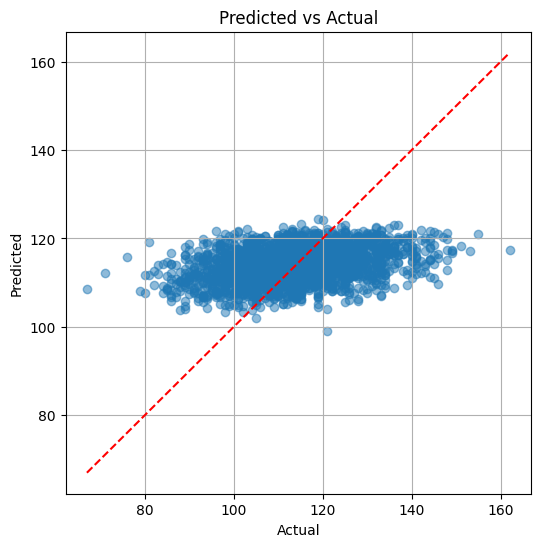

In [331]:
# Predict on test set
y_pred = model.predict(X_test_scaled)

# Compute MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {mae:.2f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(True)
plt.show()

In [332]:
print(f"Actual std: {np.std(y_test):.2f}")
print(f"Predicted std: {np.std(y_pred):.2f}")

Actual std: 12.84
Predicted std: 3.96


# TODO:
Where is the over under coming from for these games before gambling was legal?  
Clean data: convert to ints, remove highly correlated features, remove ranks  
minutes: include to normalize overtime games  
points: normalize based on average for a season
data warehousing: store the data in a way so that it is easier to run high level queries eg. get all of the Lakers games for the 2024-2025 season: model for team, game, and season
The goal is to create sequences of the previous 5 games for each team including statistics for and statistics allowed


# Final report updates
feedforward neural network StandardScaler, no home/away, no back-to-back: 9.66
RNN, StandardScaler, window size 10, no home/away, no back-to-back: 9.66